# Convolutional Neural Networks (CNNs) 🖼️
Demonstrates a basic CNN architecture using PyTorch.

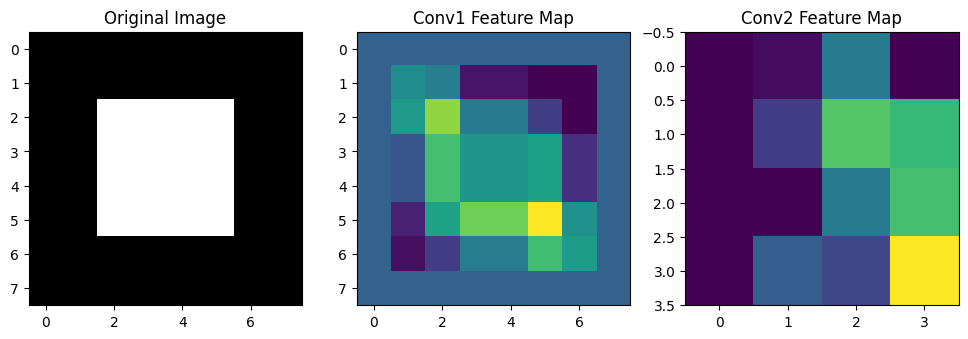

In [1]:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(4, 8, kernel_size=3, padding=1)
        
    def forward(self, x):
        x1 = torch.relu(self.conv1(x))
        x_pool = self.pool(x1)
        x2 = torch.relu(self.conv2(x_pool))
        return x1, x2

# Dummy image 8x8
img = torch.zeros((1, 1, 8, 8))
img[0, 0, 2:6, 2:6] = 1.0

model = SimpleCNN()
with torch.no_grad():
    x1, x2 = model(img)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img[0, 0].numpy(), cmap='gray')
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(x1[0, 0].numpy(), cmap='viridis')
plt.title('Conv1 Feature Map')

plt.subplot(1, 3, 3)
plt.imshow(x2[0, 0].numpy(), cmap='viridis')
plt.title('Conv2 Feature Map')
plt.show()


## 🚀 Real-World CNN: MNIST Digit Recognition
Instead of just a dummy image, let's look at how a CNN handles real digits.

  0%|                                                                              | 0.00/9.91M [00:00<?, ?B/s]

  5%|███▍                                                                  | 492k/9.91M [00:00<00:01, 4.86MB/s]

 11%|███████▌                                                             | 1.08M/9.91M [00:00<00:01, 5.07MB/s]

 19%|████████████▊                                                        | 1.84M/9.91M [00:00<00:01, 6.14MB/s]

 25%|█████████████████▌                                                   | 2.52M/9.91M [00:00<00:01, 6.42MB/s]

...

 30%|████████████████████▊                                                 | 492k/1.65M [00:00<00:00, 4.76MB/s]

 78%|█████████████████████████████████████████████████████▍               | 1.28M/1.65M [00:00<00:00, 6.25MB/s]

100%|█████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 6.09MB/s]

  0%|                                                                              | 0.00/4.54k [00:00<?, ?B/s]

100%|█████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 2.71MB/s]

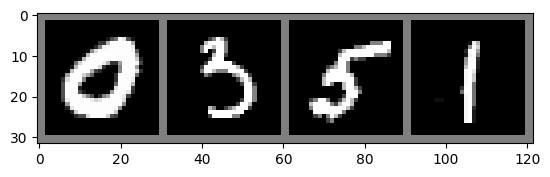

In [2]:

import torch
import torchvision
import torchvision.transforms as transforms

# Load a small batch of MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True)

dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(images))


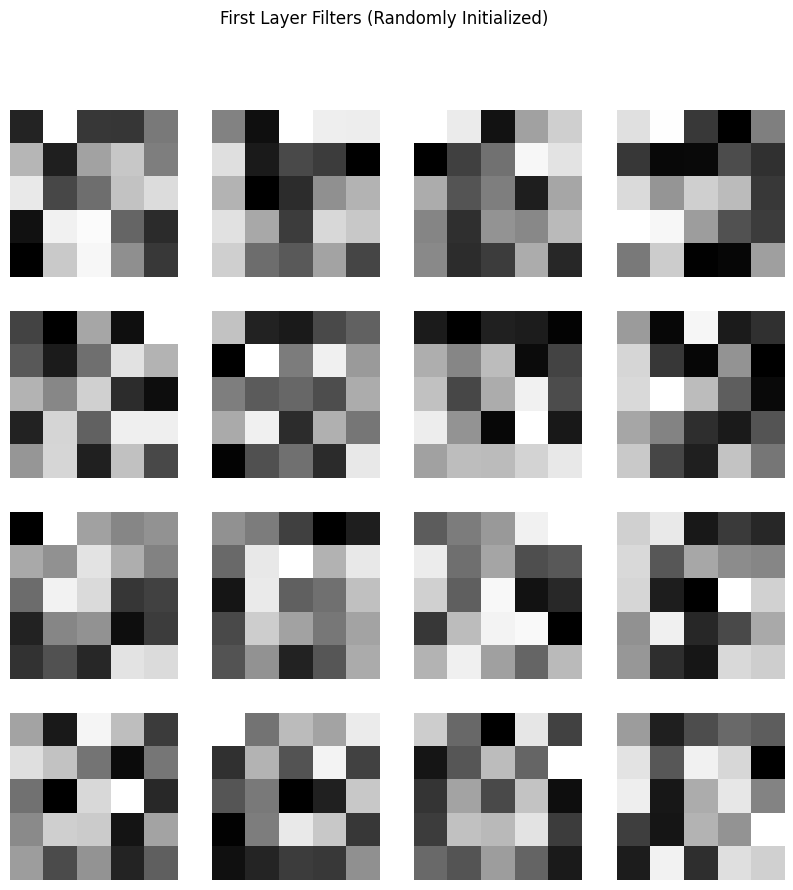

In [3]:

# Simple CNN for MNIST
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.fc1 = nn.Linear(32 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 4 * 4)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate and show filter visualizations (first layer)
net = MNIST_CNN()
filters = net.conv1.weight.data
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(filters[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle('First Layer Filters (Randomly Initialized)')
plt.show()
